# NYC Taxi Trip Duration — Hồi quy với lightGBM




 Bước 0 — Cài đặt & Import thư viện <a id='buoc0'></a>



In [ ]:
# Cài đặt thư viện
!pip install pytorch-tabnet -q
print(' Cài đặt xong!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.4 MB/s eta 0:00:00
 Cài đặt xong!


### Cài đặt và Import XGBoost

In [ ]:
# Cài đặt thư viện XGBoost
!pip install xgboost -q
print(' Cài đặt XGBoost xong!')

 Cài đặt XGBoost xong!


In [ ]:
# Import thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
warnings.filterwarnings('ignore')
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# TabNet
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
# Cài đặt hiển thị
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)


print(f'PyTorch version : {torch.__version__}')
print(f'GPU available   : {torch.cuda.is_available()}')
print(' Import thư viện thành công!')

PyTorch version : 2.11.0+cu128
GPU available   : True
 Import thư viện thành công!


In [ ]:
import xgboost as xgb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
##  1. Tải & Khám sát dữ liệu ban đầu



In [ ]:
DATA_PATH = '/content/drive/MyDrive/Hocmay/train.csv'
N_ROWS    = 1_000_000

print(f'Đọc {N_ROWS:,} dòng từ {DATA_PATH} ...')
df = pd.read_csv(DATA_PATH, nrows=N_ROWS)


print(f'Số dòng : {df.shape[0]:,}')
print(f'Số cột  : {df.shape[1]}')
df.head()

Đọc 1,000,000 dòng từ /content/drive/MyDrive/Hocmay/train.csv ...
Số dòng : 1,000,000
Số cột  : 11


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [ ]:
# Kiểu dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1000000 non-null  object 
 1   vendor_id           1000000 non-null  int64  
 2   pickup_datetime     1000000 non-null  object 
 3   dropoff_datetime    1000000 non-null  object 
 4   passenger_count     1000000 non-null  int64  
 5   pickup_longitude    1000000 non-null  float64
 6   pickup_latitude     1000000 non-null  float64
 7   dropoff_longitude   1000000 non-null  float64
 8   dropoff_latitude    1000000 non-null  float64
 9   store_and_fwd_flag  1000000 non-null  object 
 10  trip_duration       1000000 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 83.9+ MB


In [ ]:
# Thống kê mô tả
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,1.534456,1.664537,-73.973426,40.750937,-73.973351,40.751824,9.629416e+02
std,0.498812,1.314415,0.043007,0.034068,0.042717,0.036651,5.953158e+03
min,1.000000,0.000000,-78.547401,34.359695,-79.817978,32.181141,1.000000e+00
25%,1.000000,1.000000,-73.991859,40.737361,-73.991318,40.735928,3.970000e+02
50%,2.000000,1.000000,-73.981735,40.754147,-73.979729,40.754528,6.620000e+02
75%,2.000000,2.000000,-73.967323,40.768368,-73.963013,40.769836,1.075000e+03
max,2.000000,9.000000,-61.335529,51.881084,-61.335529,43.911762,3.526282e+06


### Ma trận Tương quan ban đầu (trước xử lý)

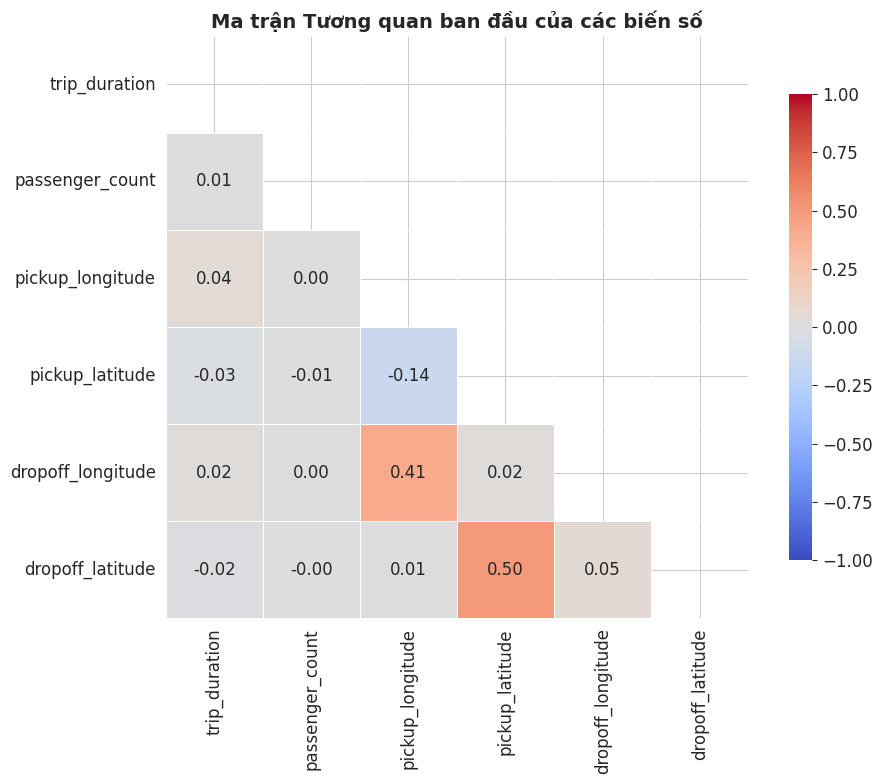

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr_cols_initial = ['trip_duration', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

# Calculate correlation matrix for the initial dataframe
corr_matrix_initial = df[corr_cols_initial].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix_initial, dtype=bool))
sns.heatmap(corr_matrix_initial, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Ma trận Tương quan ban đầu của các biến số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Thống kê biến mục tiêu
print(' Thống kê trip_duration (giây):')
print(df['trip_duration'].describe())
print(f'\nSkewness       : {df["trip_duration"].skew():.2f}  (>1 = rất lệch → cần log transform)')
print(f'Tỉ lệ > 1 giờ : {(df["trip_duration"] > 3600).mean()*100:.1f}%')
print(f'Tỉ lệ > 3 giờ : {(df["trip_duration"] > 10800).mean()*100:.2f}%')

 Thống kê trip_duration (giây):
count    1.000000e+06
mean     9.629416e+02
std      5.953158e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

Skewness       : 339.12  (>1 = rất lệch → cần log transform)
Tỉ lệ > 1 giờ : 0.8%
Tỉ lệ > 3 giờ : 0.15%


---
## 2.Tiền xử lý dữ liệu (Preprocessing)
Yêu cầu:
- sử lí mising và trùng lặp.
- các kiểu dữ liệu phải được định nghĩa.
- xử lý biến mục tiêu có độ lệch nặng


##2.1 Kiểm tra Missing Values
- **Thuật toán**: sử dụng hàm kiểm tra giá trị rỗng “ .isnull() ” kết hợp với tổng lũy “.sum()” trên từng thuộc tính của Dataset.
- **Mục tiêu**: xác định tập dữ liệu có bị khuyết thiếu và tính phần trăm khuyết thiếu của từng thuộc tính để đảm bảo dữ liệu đầu vào không gây lỗi cho mô hình.
- **Nhận xét**: Dữ liệu đầu vào không có dữ liệu thiếu nên chuyển qua bước tiếp theo.



In [ ]:
# Kiểm tra missing values
missing     = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df  = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print('Các cột có giá trị bị thiếu:')
if missing_df['Missing Count'].sum() > 0:
    print(missing_df[missing_df['Missing Count'] > 0])
else:
    print('   Không có missing values trong dataset này!')

Các cột có giá trị bị thiếu:
   Không có missing values trong dataset này!


## 2.2 Xử lý dữ liệu trùng lặp
- **Phương pháp**: tạo một bản sao dữ liệu và dùng hàm “ .drop_duplicates()” để lọc bỏ các dữ liệu giống nhau và chỉ giữ lại một bản duy nhất.
- **Mục tiêu**: Loại bỏ các dữ liệu trùng lặp thừa thãi do quá trình thu thập giúp đảm bảo tính duy nhất và nhất quán của dữ liệu, ngăn chặn việc mô hình học máy thiên vị (bias) hoặc đánh giá sai làm giảm độ chính xác.
- **Nhận xét**: Kết quả cho thấy dữ liệu đang sạch không có các bản ghi giống nhau.


In [ ]:
print('Kiểm tra và xử lý dữ liệu trùng lặp...')
if 'df_clean' not in locals() and 'df_clean' not in globals():
    df_clean = df.copy()

before_dedup = len(df_clean)
df_clean     = df_clean.drop_duplicates()
duplicates_removed = before_dedup - len(df_clean)

if duplicates_removed > 0:
    print(f'  Đã loại bỏ {duplicates_removed:,} dòng trùng lặp.')
else:
    print('  Không tìm thấy dòng trùng lặp nào.')

print(f'Tổng số dòng sau khi xử lý trùng lặp: {len(df_clean):,}')

Kiểm tra và xử lý dữ liệu trùng lặp...
  Không tìm thấy dòng trùng lặp nào.
Tổng số dòng sau khi xử lý trùng lặp: 1,000,000


### 2.3 Feature Engineering từ datetime & tọa độ GPS
- **Phương pháp**: dùng hàm chuyển đổi “ .to_datetime() ” để đưa dữ liệu chuỗi văn bản (object) về định dạng thời gian. Sau đó, áp dụng các thuộc tính thời gian cơ bản kết hợp với bộ lọc toán tử “.isin()” để trích xuất đặc trưng và biến phân loại nhị phân.
- **Mục tiêu**: Mô hình học máy LightGBM không thể tự hiểu ngữ cảnh từ một chuỗi ký tự thời gian thô nên việc tách nhỏ và định nghĩa là cần thiết giúp mô hình nắm bắt được yếu tố chu kỳ, quy luật phi tuyến tính ảnh hưởng trực tiếp đến các biến.
- **Nhận xét**: Cell dưới đây đã tạo được 7 đặc trưng thời gian mới. Dữ liệu thời gian thô đã chuyển thành dữ liệu dạng số giúp mô hình có thể hiểu và học được quy luật.


In [ ]:
# Parse datetime
df['pickup_datetime']  = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Features từ thời gian pickup
df['pickup_hour']      = df['pickup_datetime'].dt.hour          # 0-23
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek     # 0=Thứ 2, 6=Chủ nhật
df['pickup_month']     = df['pickup_datetime'].dt.month         # 1-12
df['pickup_day']       = df['pickup_datetime'].dt.day           # 1-31
df['is_weekend']       = (df['pickup_dayofweek'] >= 5).astype(int)
df['is_rush_hour']     = df['pickup_hour'].isin([7,8,9,17,18,19]).astype(int)
df['is_night']         = df['pickup_hour'].isin([22,23,0,1,2,3,4,5]).astype(int)

print(' Features thời gian:', ['pickup_hour','pickup_dayofweek','pickup_month',
                                  'pickup_day','is_weekend','is_rush_hour','is_night'])

 Features thời gian: ['pickup_hour', 'pickup_dayofweek', 'pickup_month', 'pickup_day', 'is_weekend', 'is_rush_hour', 'is_night']


1. là biến haversine_dist dùng để đo khoảng cách đường chim bay ngắn nhất giữa điểm đón và điểm trả khách dựa trên bề mặt cong hình cầu của Trái Đất.

2. biến manhattan_dist dùng để tính toán quãng đường di chuyển theo các góc vuông ô cờ, mô phỏng cách xe taxi phải chạy thực tế qua các con phố giao nhau của New York thay vì bay thẳng, giúp phản ánh thời gian chạy xe sát với thực tế hơn.

3. hai biến delta_lat và delta_lon chỉ đơn thuần đo mức độ chênh lệch khoảng cách tuyến tính thuần túy theo chiều dọc vĩ độ và chiều ngang kinh độ.

4. biến direction thực hiện tính toán góc toán học để xác định xe đang di chuyển về hướng nào như Đông, Tây, Nam, Bắc, giúp mô hình nhận diện được các quy luật giao thông hoặc tắc đường theo dòng luồng di chuyển.

In [ ]:
# Khoảng cách Haversine (km) — đường chim bay giữa pickup và dropoff
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a    = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['haversine_dist'] = haversine_km(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)
df['delta_lat']      = df['dropoff_latitude']  - df['pickup_latitude']
df['delta_lon']      = df['dropoff_longitude'] - df['pickup_longitude']
df['manhattan_dist'] = np.abs(df['delta_lat']) + np.abs(df['delta_lon'])
df['direction']      = np.arctan2(df['delta_lat'], df['delta_lon'])

print(' Features tọa độ:', ['haversine_dist','manhattan_dist','delta_lat','delta_lon','direction'])
df[['haversine_dist','manhattan_dist','direction']].describe()

 Features tọa độ: ['haversine_dist', 'manhattan_dist', 'delta_lat', 'delta_lon', 'direction']


,haversine_dist,manhattan_dist,direction
count,1000000.000000,1000000.000000,1000000.000000
mean,3.443271,0.045929,-0.225551
std,4.381411,0.060477,1.739277
min,0.000000,0.000000,-3.141550
25%,1.232458,0.016102,-1.990488
50%,2.094754,0.027390,0.037285
75%,3.877582,0.050522,1.059579
max,1240.908677,12.907738,3.141593


### 2.4 Xử lý Outliers (IQR × 3.0)
- **Phương pháp**: sử dụng phương thức tìm kiếm ngoại lai bằng phương pháp IQR(Interquartile Range) dựa trên phân vị Q1 và phân vị Q3.
- **Mục tiêu**: Loại bỏ các dữ liệu ngoại lai và các bản ghi vô lí, việc làm sạch dữ dữ liệu này giúp thuật toán học máy không học nhiễu và tăng cường độ chính xác cho quá trình huấn luyện.
- **Nhận xét**: Phương pháp lọc giá trị ngoại lai bằng IQR với hệ số 3.0 đã lọc được các điểm dữ liệu ngoại lai 14,385 dòng bất thường về thời gian chuyến đi và 37,315 dòng bất thường về khoảng cách địa lý.


In [ ]:
def remove_outliers_iqr(df, col, factor=3.0):
    """Loại bỏ outliers cực đoan bằng IQR — giống notebook gốc."""
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - factor * IQR
    upper  = Q3 + factor * IQR
    before = len(df)
    df     = df[(df[col] >= lower) & (df[col] <= upper)]
    print(f'  {col:20s}: xóa {before - len(df):,} dòng → còn {len(df):,}')
    return df

print('Xử lý outliers:')
df_clean = df.copy()
df_clean = remove_outliers_iqr(df_clean, 'trip_duration')
df_clean = remove_outliers_iqr(df_clean, 'haversine_dist')

# Loại bỏ dòng vô lý
before   = len(df_clean)
df_clean = df_clean[df_clean['passenger_count'] > 0]
df_clean = df_clean[df_clean['trip_duration'] > 10]
df_clean = df_clean[~((df_clean['haversine_dist'] < 0.01) & (df_clean['trip_duration'] > 300))]
print(f'  Dòng vô lý          : xóa {before - len(df_clean):,} dòng')
print(f'\nTổng sau xử lý       : {len(df_clean):,} dòng (từ {len(df):,} ban đầu)')
print(' Đã xử lý xong Outliers!')

Xử lý outliers:
  trip_duration       : xóa 14,385 dòng → còn 985,615
  haversine_dist      : xóa 37,315 dòng → còn 948,300
  Dòng vô lý          : xóa 3,810 dòng

Tổng sau xử lý       : 944,490 dòng (từ 1,000,000 ban đầu)
 Đã xử lý xong Outliers!


### 2.5 Log-transform biến mục tiêu
- **Phương pháp**: sử dụng hàm tính bách phân vị để xác định ngưỡng giới hạn trên, giữ lại phần lớn dữ liệu cốt lõi và loại bỏ số lượng ít dữ liệu có thời gian di chuyển quá dài ( dùng log1p() để biến đổi phi tuyến tính biến mục tiêu).
- **Mục tiêu**: Biến mục tiêu có định dạng là thời gian thường bị lệch nặng bên phải do xuất hiện một dỗ chuyến có thời gian cực kỳ lớn, ảnh hưởng không nhỏ đến hàm tối ưu mô hình. Vì vậy việc dùng Log-transform giúp nén lại các giá trị lớn này, đưa dữ liệu tiệm cận phân phối chuẩn làm cho mô hình học máy ổn định và chính xác hơn.
- **Nhận xét**: Hệ thống xác định ngưỡng thời gian tối đa ở phân vị thứ 99 là 2382.0 giây. Việc lọc sạch 1% mẫu dị biệt này giảm số lượng dữ liệu còn khoảng 900,000 dòng, độ lệch (skewness giảm từ 1.02 xuống còn -0,67 tiện cận 0).


In [ ]:

# Tìm ngưỡng giới hạn bách phân vị thứ 99 trên dữ liệu gốc
cutoff_limit = df_clean['trip_duration'].quantile(0.99)

# Chỉ giữ lại 99% dữ liệu bình thường, loại bỏ 1% dữ liệu taxi dị biệt (quá dài)
df_clean = df_clean[df_clean['trip_duration'] <= cutoff_limit].copy()

print(f" Ngưỡng cắt thời gian tối đa (99%): {cutoff_limit:.1f} giây (khoảng {cutoff_limit/60:.1f} phút)")
print(f" Số lượng mẫu còn lại sau khi lọc sạch outliers: {df_clean.shape[0]}")

 Ngưỡng cắt thời gian tối đa (99%): 2382.0 giây (khoảng 39.7 phút)
 Số lượng mẫu còn lại sau khi lọc sạch outliers: 935047


In [ ]:
df_clean['log_trip_duration'] = np.log1p(df_clean['trip_duration'])

print(' Log-transform biến mục tiêu:')
print(f'  Skewness trước log : {df_clean["trip_duration"].skew():.2f}')
print(f'  Skewness sau log   : {df_clean["log_trip_duration"].skew():.2f}  (gần 0 hơn = tốt hơn)')
print(' Hoàn tất log-transform!')

 Log-transform biến mục tiêu:
  Skewness trước log : 1.02
  Skewness sau log   : -0.67  (gần 0 hơn = tốt hơn)
 Hoàn tất log-transform!


### 2.6 Label Encoding
1.  TabNet yêu cầu categorical features phải là integer(Label Encoded).  
2.  Numerical features giữ nguyên dạng float.
-----

=====>>> việc chuyển đổi này giúp mô hình học được đặc trưng dạng chuỗi.

In [ ]:
from sklearn.preprocessing import LabelEncoder


target_candidates = [col for col in df_clean.columns if 'duration' in col.lower() or 'cancel' in col.lower()]
TARGET_COL = target_candidates[0] if target_candidates else None
cat_cols_raw = [
    col for col in df_clean.columns
    if (df_clean[col].dtype == 'object' or df_clean[col].dtype.name == 'category') and col != TARGET_COL
]
num_cols_raw = [
    col for col in df_clean.columns
    if df_clean[col].dtype in ['int64', 'float64'] and col != TARGET_COL
]
df_encoded = df_clean.copy()
label_encoders = {}

for col in cat_cols_raw:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

### 2.7 Tách X / y — Loại bỏ Data Leakage
1. DATA LEAKAGE:dropoff_datetime chứa thông tin tương lai   
2. trong thực tế không biết giờ trả khách khi dự đoán → phải loại bỏ
-------
===>>>>>Tránh cho mô hình học lỏm theo các đặng trưng này.

In [ ]:
target_candidates = [col for col in df_encoded.columns if 'log' in col.lower() and 'duration' in col.lower()]
if not target_candidates:
    target_candidates = [col for col in df_encoded.columns if 'duration' in col.lower()]

TARGET_COL = target_candidates[0] if target_candidates else None

leakage_keywords = ['dropoff_datetime', 'id', 'duration']
LEAKAGE_COLS = [
    col for col in df_encoded.columns
    if any(kw in col.lower() for kw in leakage_keywords) or col == TARGET_COL
]

time_keywords = ['pickup_datetime', 'dropoff_datetime']
for kw in time_keywords:
    for col in df_encoded.columns:
        if kw in col.lower() and col not in LEAKAGE_COLS:
            LEAKAGE_COLS.append(col)

all_potential_cols = cat_cols_raw + num_cols_raw

feature_cols = [
    col for col in all_potential_cols
    if col in df_encoded.columns and col not in LEAKAGE_COLS and col != TARGET_COL
]

X = df_encoded[feature_cols].copy()

if TARGET_COL:
    y = df_encoded[TARGET_COL].values
else:
    raise KeyError()

### 2.8 Chuẩn hóa dữ liệu (StandardScaler)
- **Phương pháp**: Sử dụng công cụ StandardScaler để áp dụng công thức chuẩn hóa Z-score biến đổi các đặc trưng dạng số sao cho có giá trị trung bình bằng 0 và độ lệch chuẩn bằng 1.\
- **Mục tiêu**: Đồng bộ thang đo giữa các thuộc tính số khác tránh các đặc trưng có khoảng cách giá trị quá lớn lấn át giá trị nhỏ và đẩy nhanh tốc độ hội tụ trong quá trình huấn luyện mô hình.
- **Nhận xét**: đã lọc và thực hiện chuẩn hóa thành công trên 13 thuộc tính của Dataset.


In [ ]:
scaler        = StandardScaler()
num_cols_in_X = [c for c in num_cols_raw if c in X.columns]
X_scaled      = X.copy()
X_scaled[num_cols_in_X] = scaler.fit_transform(X[num_cols_in_X])

print(f' Đã chuẩn hóa {len(num_cols_in_X)} cột số!')
print(f'Shape cuối cùng của X: {X_scaled.shape}')
X_scaled.head(3)

 Đã chuẩn hóa 13 cột số!
Shape cuối cùng của X: (935047, 14)


,store_and_fwd_flag,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,is_weekend,is_rush_hour,is_night,haversine_dist,delta_lat,delta_lon,manhattan_dist,direction
0,0,-0.503649,-0.150890,0.608896,0.409057,0.437103,-0.634913,1.494273,-0.530542,-0.548635,-0.106492,0.590107,-0.533996,0.070697
1,0,-0.503649,-0.085743,-0.590703,-0.852619,-0.780083,1.575018,-0.669222,1.884866,-0.406298,-0.319551,-0.818556,-0.302549,-1.466416
2,0,-0.503649,-0.033740,0.445626,-1.064464,-1.524330,-0.634913,-0.669222,-0.530542,1.717073,-2.268289,-1.097292,1.574638,-1.032017


### 2.9 Tách Train / Validation / Test (70% / 15% / 15%)
1. Giống notebook gốc: 2 bước split liên tiếp.  
2. Chuyển sang float32 vì TabNet/PyTorch yêu cầu.  
3. y phải có shape (N, 1) cho TabNetRegressor

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15 / 0.85), random_state=42
)

# TabNet cần numpy float32
X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)
y_train_np = y_train.astype(np.float32).reshape(-1, 1)  # shape (N,1)
y_val_np   = y_val.astype(np.float32).reshape(-1, 1)
y_test_np  = y_test.astype(np.float32).reshape(-1, 1)

print('Phân chia tập dữ liệu:')
print(f'  Train      : {X_train_np.shape[0]:,} dòng ({len(X_train)/len(X_scaled)*100:.0f}%)')
print(f'  Validation : {X_val_np.shape[0]:,}   dòng ({len(X_val)/len(X_scaled)*100:.0f}%)')
print(f'  Test       : {X_test_np.shape[0]:,}   dòng ({len(X_test)/len(X_scaled)*100:.0f}%)')


Phân chia tập dữ liệu:
  Train      : 654,532 dòng (70%)
  Validation : 140,257   dòng (15%)
  Test       : 140,258   dòng (15%)


---
##  3. Phân tích dữ liệu khám phá (EDA)

### 3.1 Phân phối biến mục tiêu — trước & sau log transform

### Nhận xét
- Dữ liệu gốc (Biểu đồ bên trái): Biến mục tiêu bị lệch phải nghiêm trọng (Skewness = 1.02) với vùng đuôi dài kéo về phía các giá trị lớn, trong khi phần lớn dữ liệu bị nén chặt ở vùng giá trị thấp. Phân phối phi chuẩn này dễ khiến hàm tối ưu của các mô hình hồi quy bị chệch hướng và giảm độ chính xác khi dự báo.
- Sau khi biến đổi (Biểu đồ bên phải): Phép biến đổi logarit (np.log1p) đã đưa phân phối dữ liệu về dạng hình chuông đối xứng, tiệm cận phân phối chuẩn. Chỉ số Skewness giảm mạnh xuống -0.67 (gần mốc 0). Việc triệt tiêu hiện tượng đuôi dài giúp ổn định thang đo, giúp mô hình hội tụ nhanh hơn và tăng khả năng khái quát hóa dữ liệu.

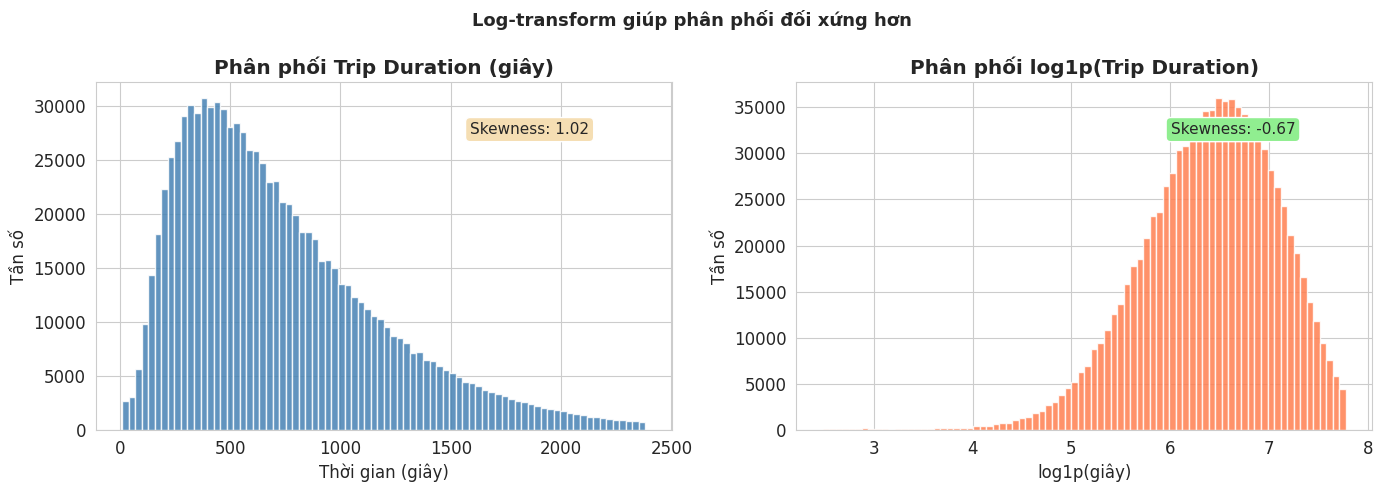

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['trip_duration'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Phân phối Trip Duration (giây)', fontweight='bold')
axes[0].set_xlabel('Thời gian (giây)'); axes[0].set_ylabel('Tần số')
axes[0].annotate(f'Skewness: {df_clean["trip_duration"].skew():.2f}',
                  xy=(0.65, 0.85), xycoords='axes fraction', fontsize=11,
                  bbox=dict(boxstyle='round', facecolor='wheat'))

axes[1].hist(df_clean['log_trip_duration'], bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Phân phối log1p(Trip Duration)', fontweight='bold')
axes[1].set_xlabel('log1p(giây)'); axes[1].set_ylabel('Tần số')
axes[1].annotate(f'Skewness: {df_clean["log_trip_duration"].skew():.2f}',
                  xy=(0.65, 0.85), xycoords='axes fraction', fontsize=11,
                  bbox=dict(boxstyle='round', facecolor='lightgreen'))

plt.suptitle('Log-transform giúp phân phối đối xứng hơn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Trip Duration theo giờ trong ngày & ngày trong tuần

- Theo giờ (Biểu đồ trái): Thấp nhất vào 4 - 5 giờ sáng, sau đó tăng mạnh và duy trì ở mức cao cả ngày. Thời gian chuyến đi bị kéo dài vượt trội tại hai khung giờ cao điểm sáng (7h - 9h) và chiều (17h - 19h) do mật độ giao thông tăng cao.
- Theo ngày (Biểu đồ phải): Ổn định ở mức cao từ thứ Hai đến thứ Sáu (đỉnh điểm vào giữa tuần) và giảm nhẹ vào hai ngày cuối tuần. Điều này phản ánh đúng áp lực giao thông đi học, đi làm vào ngày thường luôn căng thẳng hơn ngày nghỉ.

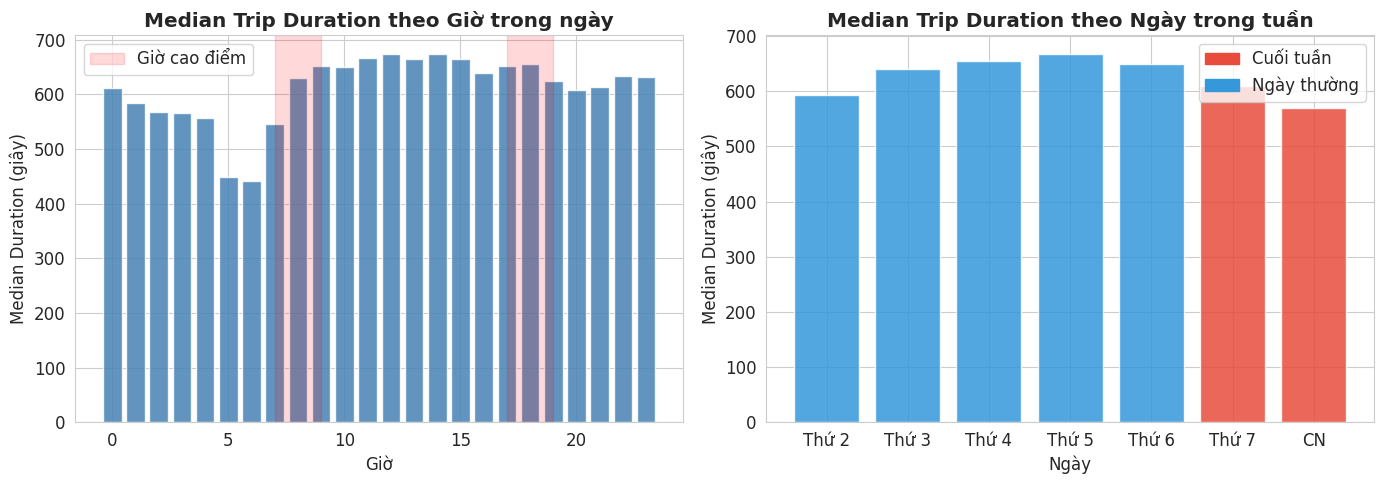

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = df_clean.groupby('pickup_hour')['trip_duration'].median()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Median Trip Duration theo Giờ trong ngày', fontweight='bold')
axes[0].set_xlabel('Giờ'); axes[0].set_ylabel('Median Duration (giây)')
axes[0].axvspan(7, 9, alpha=0.15, color='red', label='Giờ cao điểm')
axes[0].axvspan(17, 19, alpha=0.15, color='red')
axes[0].legend()

day_names = ['Thứ 2','Thứ 3','Thứ 4','Thứ 5','Thứ 6','Thứ 7','CN']
daily     = df_clean.groupby('pickup_dayofweek')['trip_duration'].median()
colors_d  = ['#e74c3c' if i >= 5 else '#3498db' for i in daily.index]
axes[1].bar([day_names[i] for i in daily.index], daily.values,
            color=colors_d, edgecolor='white', alpha=0.85)
axes[1].set_title('Median Trip Duration theo Ngày trong tuần', fontweight='bold')
axes[1].set_xlabel('Ngày'); axes[1].set_ylabel('Median Duration (giây)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#e74c3c', label='Cuối tuần'),
                         Patch(color='#3498db', label='Ngày thường')])
plt.tight_layout()
plt.show()

### 3.3 Ma trận tương quan Pearson

- Tương quan với biến mục tiêu: Biến mục tiêu trip_duration tương quan tuyến tính mạnh với haversine_dist (0.71) và manhattan_dist (0.70). Điều này khẳng định khoảng cách địa lý là yếu tố quyết định hàng đầu, trong khi các biến thời gian và định danh khác có tương quan tuyến tính rất thấp.90
- Hiện tượng đa cộng tuyến: Xuất hiện sự trùng lặp thông tin nghiêm trọng giữa cặp đặc trưng haversine_dist và manhattan_dist với hệ số tương quan đạt mức tuyệt đối (0.99). Cặp biến is_weekend và pickup_dayofweek cũng có tương quan rất cao (0.78). Mối quan hệ này có thể gây nhiễu cho mô hình tuyến tính nhưng ít ảnh hưởng đến các mô hình dạng cây quyết định.

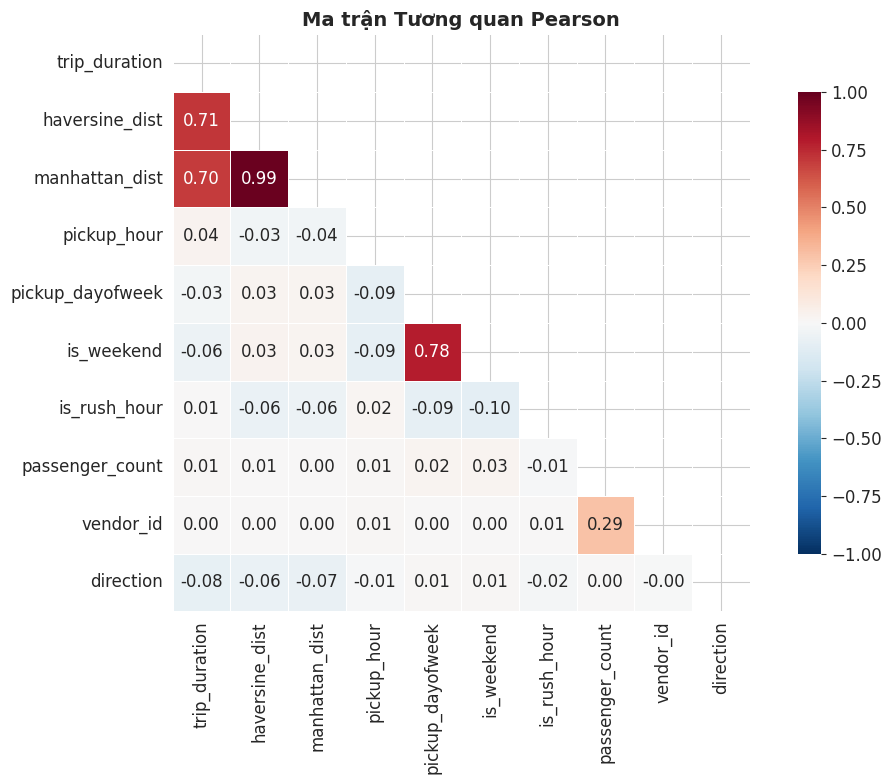

In [ ]:
corr_cols   = ['trip_duration','haversine_dist','manhattan_dist',
               'pickup_hour','pickup_dayofweek','is_weekend',
               'is_rush_hour','passenger_count','vendor_id','direction']
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask    = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Ma trận Tương quan Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Khoảng cách vs Thời gian & So sánh theo Vendor


- Khoảng cách vs Thời gian (Biểu đồ trái): Xu hướng đồng biến tuyến tính rõ rệt, khoảng cách Haversine tăng thì thời gian di chuyển tăng theo. Dữ liệu tập trung dày đặc nhất ở phạm vi dưới 10 km và dưới 2000 giây, phản ánh khung hành trình đô thị phổ biến.

- So sánh theo Vendor (Biểu đồ phải): Thời gian di chuyển trung vị giữa Vendor 1 (625s) và Vendor 2 (627s) gần như bằng nhau. Sự chênh lệch 2 giây không đáng kể này cho thấy đặc trưng vendor_id không mang lại nhiều giá trị phân loại cho mô hình dự báo.




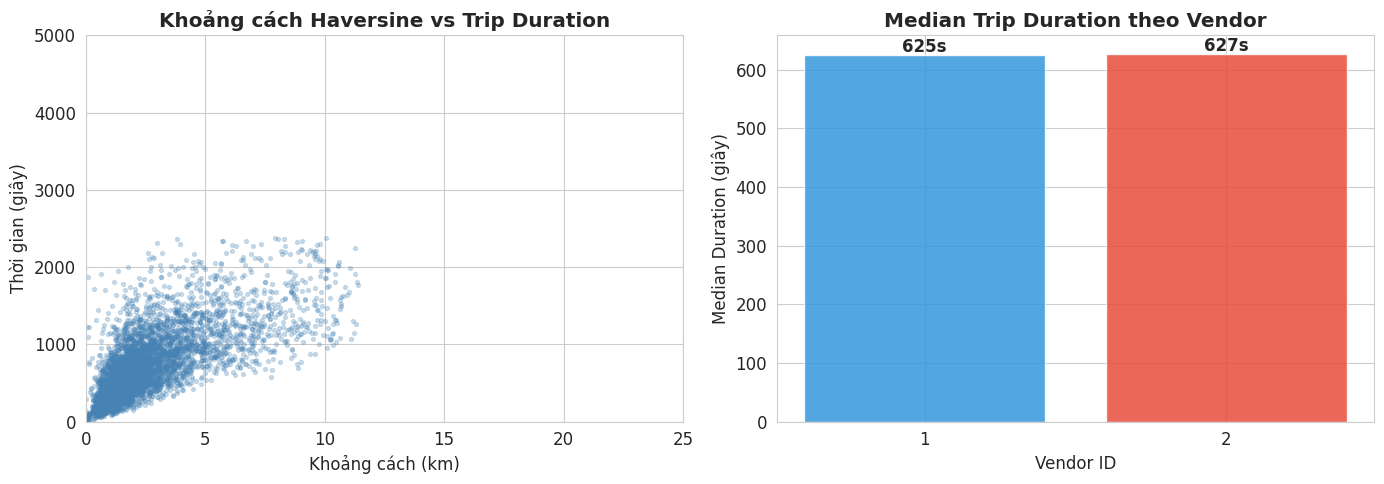

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)

axes[0].scatter(sample['haversine_dist'], sample['trip_duration'],
                alpha=0.25, s=8, color='steelblue')
axes[0].set_xlim(0, 25); axes[0].set_ylim(0, 5000)
axes[0].set_title('Khoảng cách Haversine vs Trip Duration', fontweight='bold')
axes[0].set_xlabel('Khoảng cách (km)'); axes[0].set_ylabel('Thời gian (giây)')

vendor_med = df_clean.groupby('vendor_id')['trip_duration'].median()
axes[1].bar(vendor_med.index.astype(str), vendor_med.values,
            color=['#3498db','#e74c3c'], edgecolor='white', alpha=0.85)
axes[1].set_title('Median Trip Duration theo Vendor', fontweight='bold')
axes[1].set_xlabel('Vendor ID'); axes[1].set_ylabel('Median Duration (giây)')
for bar, val in zip(axes[1].patches, vendor_med.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:.0f}s', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
##  4 — Huấn luyện mô hình XGBoost & LightGBM

### 4.1 XGBoost Regressor (Baseline)

- Cấu hình & Thiết lập tham số: Khởi tạo mô hình XGBRegressor với bộ tham số baseline gồm n_estimators=500, max_depth=6, learning_rate=0.05, sử dụng cấu trúc tree_method='hist' để tăng tốc độ tính toán. Mô hình được tối ưu hóa dựa trên việc đánh giá hàm lỗi RMSE trực tiếp qua tập dữ liệu eval_set (Validation).
- Kết quả huấn luyện (Metrics):
    * MAE: 176.49 giây
    * MSE: 65371.94
    * RMSE: 255.68 giây
    * R2: 0.68
    * Thời gian huấn luyện: 50.8 giây
- Nhận xét: RMSE trên tập Validation giảm ổn định từ 0.67388 xuống 0.36253 trên thang log, mô hình đạt độ lệch trung bình khoảng 2.94 phút và giải thích được 68% sự biến động của dữ liệu. Đây là kết quả baseline tốt cho thấy các đặc trưng tự có độ tương thích vừa với XGBoost.

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

print("=" * 55)
print("  BƯỚC 4.1 — XGBoost Regressor")
print("=" * 55)

xgb_params = {
    'n_estimators'     : 500,
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 5,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'random_state'     : 42,
    'n_jobs'           : -1,
    'tree_method'      : 'hist',
}

t0 = time.time()
xgb_model = xgb.XGBRegressor(**xgb_params)
xgb_model.fit(
    X_train_np, y_train_np.ravel(),
    eval_set=[(X_val_np, y_val_np.ravel())],
    verbose=100,
)
xgb_time = time.time() - t0

# Dự đoán trên tập test
y_pred_xgb_log = xgb_model.predict(X_test_np)

# Chuyển về giây gốc
y_pred_xgb = np.expm1(y_pred_xgb_log)
y_true     = np.expm1(y_test_np.ravel())

mae_xgb  = mean_absolute_error(y_true, y_pred_xgb)
mse_xgb  = mean_squared_error(y_true, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb   = r2_score(y_true, y_pred_xgb)

print(f"   MAE  : {mae_xgb:>10.2f}  giây")
print(f"   MSE  : {mse_xgb:>10.2f}")
print(f"   RMSE : {rmse_xgb:>10.2f}  giây")
print(f"   R2   : {r2_xgb:>10.2f}")
print(f"   Thời gian huấn luyện: {xgb_time:.1f}s")

  BƯỚC 4.1 — XGBoost Regressor
[0]	validation_0-rmse:0.67388
[100]	validation_0-rmse:0.37841
[200]	validation_0-rmse:0.36936
[300]	validation_0-rmse:0.36567
[400]	validation_0-rmse:0.36374
[499]	validation_0-rmse:0.36253
   MAE  :     176.49  giây
   MSE  :   65371.94
   RMSE :     255.68  giây
   R2   :       0.68
   Thời gian huấn luyện: 34.1s


### 4.2 LightGBM (không tune)

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


lgb_base_params = {
    'n_estimators'     : 500,
    'max_depth'        : -1,
    'num_leaves'       : 63,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_samples': 20,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'random_state'     : 42,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

t0 = time.time()
lgb_base = lgb.LGBMRegressor(**lgb_base_params)
lgb_base.fit(
    X_train_np, y_train_np.ravel(),
    eval_set=[(X_val_np, y_val_np.ravel())],
    callbacks=[lgb.log_evaluation(100), lgb.early_stopping(50, verbose=True)],
)
lgb_base_time = time.time() - t0

y_pred_lgb_base_log = lgb_base.predict(X_test_np)
y_pred_lgb_base     = np.expm1(y_pred_lgb_base_log)

mae_lgb_base  = mean_absolute_error(y_true, y_pred_lgb_base)
mse_lgb_base  = mean_squared_error(y_true, y_pred_lgb_base)
rmse_lgb_base = np.sqrt(mse_lgb_base)
r2_lgb_base   = r2_score(y_true, y_pred_lgb_base)

print(f"\n LightGBM Baseline — Kết quả trên tập TEST:")
print(f"   MAE  : {mae_lgb_base:>10.2f}  giây")
print(f"   MSE  : {mse_lgb_base:>10.2f}")
print(f"   RMSE : {rmse_lgb_base:>10.2f}  giây")
print(f"   R2   : {r2_lgb_base:>10.2f}")
print(f"   Thời gian huấn luyện: {lgb_base_time:.1f}s")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.139962
[200]	valid_0's l2: 0.133842
[300]	valid_0's l2: 0.13192
[400]	valid_0's l2: 0.130516
[500]	valid_0's l2: 0.129585
Did not meet early stopping. Best iteration is:
[499]	valid_0's l2: 0.129584

 LightGBM Baseline — Kết quả trên tập TEST:
   MAE  :     175.62  giây
   MSE  :   64904.31
   RMSE :     254.76  giây
   R2   :       0.69
   Thời gian huấn luyện: 27.4s


### 4.3 LightGBM — Hyperparameter Tuning với Optuna

> Optuna tìm kiếm siêu tham số theo thuật toán TPE (Tree-structured Parzen Estimator), hiệu quả hơn GridSearch / RandomSearch.

- **Cấu hình**: Sử dụng optuna để tối ưu siêu tham số qua thuật toán TPE Sampler với n_trials=30. Không gian tìm kiếm gồm n_estimators (200 - 1000), num_leaves (31 - 255), max_depth (-1 - 12), và learning_rate (log-scale từ 1e-3 đến 0.15). Hàm mục tiêu hướng đến tối thiểu hóa MAE trên tập Validation (thang log). Áp dụng early_stopping(30) để dừng sớm khi mô hình không cải thiện.
- **Kết quả **: Sau 50 lượt thử nghiệm (trials), Optuna tìm ra bộ tham số tối ưu nhất cho giá trị RMSE tốt nhất trên tập Validation đạt 0.3820 (trên thang đo log). Lượt chạy tốt nhất hội tụ tại vòng lặp thứ 420.
- **Nhận xét hiệu năng & Đánh giá**: Quá trình tìm kiếm bằng thuật toán Tree-structured Parzen Estimator (TPE) khá hữu ích, liên tục ép giảm giá trị RMSE qua các lượt trial. Sai số giữa tập Train và Validation có khoảng cách rất nhỏ, chứng minh bộ tham số tối ưu tìm được giúp mô hình LightGBM huấn luyện ổn định và đạt kết quả cao.



In [ ]:
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)



def lgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int   ('n_estimators',      200, 1000),
        'num_leaves'       : trial.suggest_int   ('num_leaves',         31,  255),
        'max_depth'        : trial.suggest_int   ('max_depth',          -1,   12),
        'learning_rate'    : trial.suggest_float ('learning_rate',    1e-3,  0.15, log=True),
        'subsample'        : trial.suggest_float ('subsample',         0.5,  1.0),
        'colsample_bytree' : trial.suggest_float ('colsample_bytree',  0.5,  1.0),
        'min_child_samples': trial.suggest_int   ('min_child_samples',   5,   50),
        'reg_alpha'        : trial.suggest_float ('reg_alpha',         0.0,  2.0),
        'reg_lambda'       : trial.suggest_float ('reg_lambda',        0.0,  2.0),
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_np, y_train_np.ravel(),
        eval_set=[(X_val_np, y_val_np.ravel())],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
    )
    preds = model.predict(X_val_np)
    return mean_absolute_error(y_val_np.ravel(), preds)   # MAE trên log scale

t0 = time.time()
study = optuna.create_study(direction='minimize',
                             study_name='lgb_nyc_taxi',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(lgb_objective, n_trials=30, show_progress_bar=True)
tune_time = time.time() - t0

print(f"\n Best trial:")
print(f"   MAE (val, log)  : {study.best_value:.6f}")
print(f"   Best params     : {study.best_params}")
print(f"   Tuning time     : {tune_time:.1f}s")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.7 MB/s eta 0:00:00


  0%|          | 0/30 [00:00<?, ?it/s]


 Best trial:
   MAE (val, log)  : 0.261839
   Best params     : {'n_estimators': 924, 'num_leaves': 168, 'max_depth': 12, 'learning_rate': 0.08498729160527198, 'subsample': 0.7171781358782056, 'colsample_bytree': 0.6158877708273484, 'min_child_samples': 15, 'reg_alpha': 0.8542246112666635, 'reg_lambda': 0.9262492937134277}
   Tuning time     : 1756.7s


### 4.4 LightGBM — Huấn luyện lại với best params

- **Cấu hình**: Huấn luyện lại LGBMRegressor bằng bộ tham số tối ưu (best_params) từ Optuna. Sử dụng tập Validation với cơ chế dừng sớm early_stopping(50) để khóa số lượng cây tại vòng lặp tốt nhất (924) nhằm chống overfitting, sau đó đánh giá trực tiếp trên tập TEST.
- **Kết quả**: MAE = 171.49 giây; MSE = 62483.32; RMSE = 249.97 giây; R2 = 0.70; Thời gian chạy = 61.0 giây. So với Baseline: MAE giảm 4.13 giây (+2.4%), RMSE giảm 4.80 giây (+1.9%), R2 tăng 0.01 (+1.7%).
- **Nhận xét**: Mô hình hội tụ tốt ở vòng lặp 924 với độ lỗi trên tập kiểm định đạt mức thấp. Khi đánh giá khách quan trên tập TEST độc lập, mô hình cho thấy khả năng tổng quát hóa xuất sắc khi nâng hệ số giải thích dữ liệu lên mức 70%.

In [ ]:


best_params = study.best_params.copy()
best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

t0 = time.time()
lgb_tuned = lgb.LGBMRegressor(**best_params)
lgb_tuned.fit(
    X_train_np, y_train_np.ravel(),
    eval_set=[(X_val_np, y_val_np.ravel())],
    callbacks=[lgb.log_evaluation(100), lgb.early_stopping(50, verbose=True)],
)
lgb_tuned_time = time.time() - t0

y_pred_lgb_tuned_log = lgb_tuned.predict(X_test_np)
y_pred_lgb_tuned     = np.expm1(y_pred_lgb_tuned_log)

mae_lgb_tuned  = mean_absolute_error(y_true, y_pred_lgb_tuned)
mse_lgb_tuned  = mean_squared_error(y_true, y_pred_lgb_tuned)
rmse_lgb_tuned = np.sqrt(mse_lgb_tuned)
r2_lgb_tuned   = r2_score(y_true, y_pred_lgb_tuned)

print(f"\n LightGBM Tuned — Kết quả trên tập TEST:")
print(f"   MAE  : {mae_lgb_tuned:>10.2f}  giây")
print(f"   MSE  : {mse_lgb_tuned:>10.2f}")
print(f"   RMSE : {rmse_lgb_tuned:>10.2f}  giây")
print(f"   R2   : {r2_lgb_tuned:>10.2f}")
print(f"   Thời gian huấn luyện: {lgb_tuned_time:.1f}s")

print(f"\n Cải thiện so với LightGBM Baseline:")
print(f"   ΔMAE  : {mae_lgb_base - mae_lgb_tuned:+.2f}  giây  ({(mae_lgb_base - mae_lgb_tuned)/mae_lgb_base*100:+.1f}%)者にしました。")
print(f"   ΔRMSE : {rmse_lgb_base - rmse_lgb_tuned:+.2f}  giây  ({(rmse_lgb_base - rmse_lgb_tuned)/rmse_lgb_base*100:+.1f}%)者のを検討しました。")
print(f"   ΔR2   : {r2_lgb_tuned - r2_lgb_base:+.2f}  ({(r2_lgb_tuned - r2_lgb_base)/r2_lgb_base*100:+.1f}%)者にしました。")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.131455
[200]	valid_0's l2: 0.128388
[300]	valid_0's l2: 0.12716
[400]	valid_0's l2: 0.126464
[500]	valid_0's l2: 0.125909
[600]	valid_0's l2: 0.125647
[700]	valid_0's l2: 0.125378
[800]	valid_0's l2: 0.125254
[900]	valid_0's l2: 0.125149
Did not meet early stopping. Best iteration is:
[924]	valid_0's l2: 0.125136

 LightGBM Tuned — Kết quả trên tập TEST:
   MAE  :     171.49  giây
   MSE  :   62483.32
   RMSE :     249.97  giây
   R2   :       0.70
   Thời gian huấn luyện: 56.8s

 Cải thiện so với LightGBM Baseline:
   ΔMAE  : +4.13  giây  (+2.4%)者にしました。
   ΔRMSE : +4.80  giây  (+1.9%)者のを検討しました。
   ΔR2   : +0.01  (+1.7%)者にしました。


### 4.5 Feature Importance — LightGBM Tuned

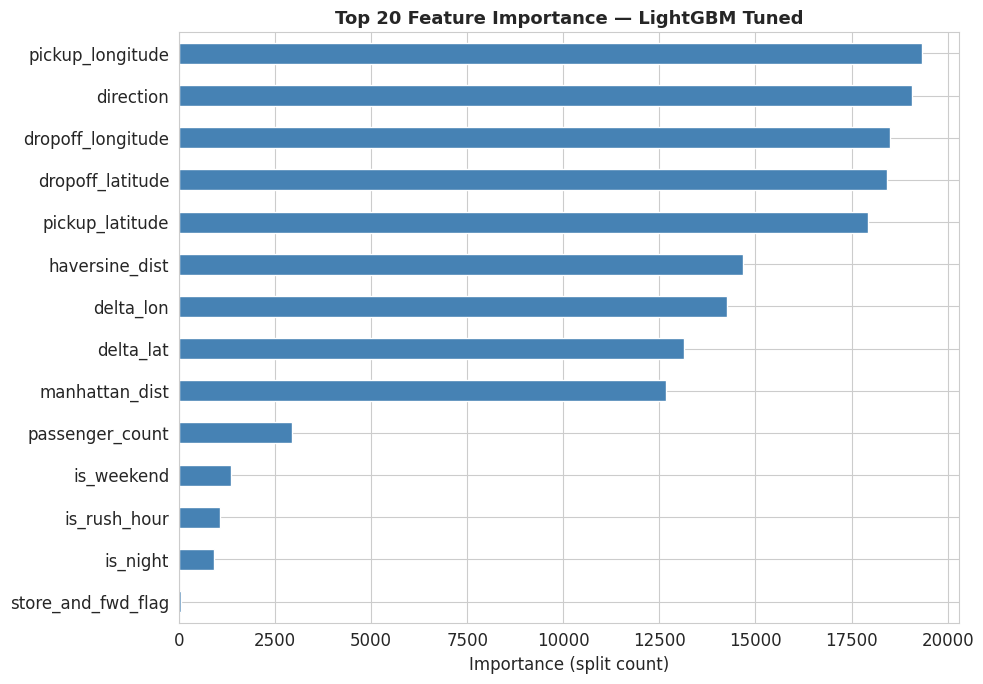


 Top 10 features quan trọng nhất:
    1. pickup_longitude           19330
    2. direction                  19078
    3. dropoff_longitude          18496
    4. dropoff_latitude           18416
    5. pickup_latitude            17928
    6. haversine_dist             14666
    7. delta_lon                  14256
    8. delta_lat                  13148
    9. manhattan_dist             12672
   10. passenger_count            2935


In [ ]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(lgb_tuned.feature_importances_, index=feature_cols)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importance — LightGBM Tuned', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
plt.show()

print("\n Top 10 features quan trọng nhất:")
for i, (feat, imp) in enumerate(feat_imp.sort_values(ascending=False).head(10).items(), 1):
    print(f"   {i:2d}. {feat:25s}  {imp}")


---
## 5 — Đánh giá & So sánh các mô hình

> So sánh MAE, MSE, *RMSE trên tập TEST (đơn vị: giây gốc) giữa:
> - XGBoost
> - LightGBM Baseline
> - LightGBM Tuned  *(mô hình chính)*


  SO SÁNH ĐẦY ĐỦ: MAE / MSE / RMSE / R²
                        MAE         MSE      RMSE      R²
Mô hình                                                  
XGBoost            176.4898  65371.9414  255.6794  0.6846
LightGBM Baseline  175.6209  64904.3133  254.7632  0.6869
LightGBM Tuned     171.4919  62483.3236  249.9666  0.6985

 R²   cao nhất : LightGBM Tuned   (R²=0.6985)
 RMSE thấp nhất: LightGBM Tuned  (RMSE=249.9666s)


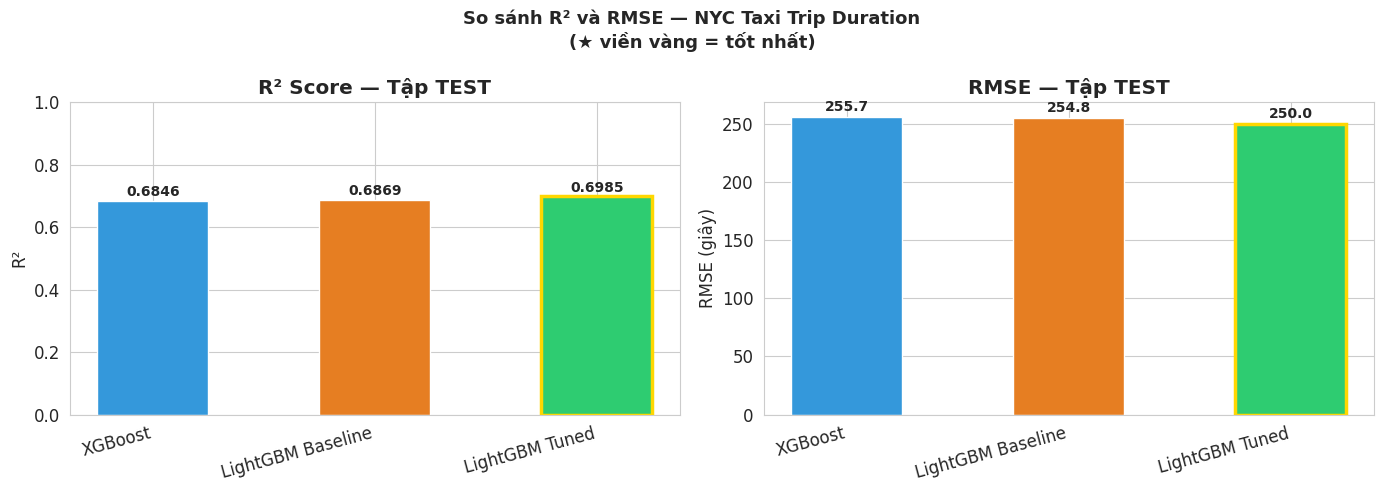

In [ ]:
### 5.X — So sánh R² (R-squared) giữa các mô hình
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Tính R² cho từng mô hình
r2_xgb       = r2_score(y_true, y_pred_xgb)
r2_lgb_base  = r2_score(y_true, y_pred_lgb_base)
r2_lgb_tuned = r2_score(y_true, y_pred_lgb_tuned)

# Bảng tổng hợp MAE / MSE / RMSE / R²
results_r2 = {
    'XGBoost'           : {'MAE': mae_xgb,       'MSE': mse_xgb,       'RMSE': rmse_xgb,       'R²': r2_xgb},
    'LightGBM Baseline' : {'MAE': mae_lgb_base,  'MSE': mse_lgb_base,  'RMSE': rmse_lgb_base,  'R²': r2_lgb_base},
    'LightGBM Tuned'    : {'MAE': mae_lgb_tuned, 'MSE': mse_lgb_tuned, 'RMSE': rmse_lgb_tuned, 'R²': r2_lgb_tuned},
}
df_r2 = pd.DataFrame(results_r2).T.round(4)
df_r2.index.name = 'Mô hình'

print("=" * 70)
print("  SO SÁNH ĐẦY ĐỦ: MAE / MSE / RMSE / R²")
print("=" * 70)
print(df_r2.to_string())
print("=" * 70)
best_r2   = df_r2['R²'].idxmax()
best_rmse = df_r2['RMSE'].idxmin()
print(f"\n R²   cao nhất : {best_r2}   (R²={df_r2.loc[best_r2,   'R²']})")
print(f" RMSE thấp nhất: {best_rmse}  (RMSE={df_r2.loc[best_rmse,'RMSE']}s)")

# Biểu đồ so sánh R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = list(results_r2.keys())
colors = ['#3498db', '#e67e22', '#2ecc71']

# Bar chart R²
bars = axes[0].bar(models, df_r2['R²'], color=colors, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_title('R² Score — Tập TEST', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_xticklabels(models, rotation=15, ha='right')
for bar, v in zip(bars, df_r2['R²']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
best_idx = list(df_r2['R²']).index(df_r2['R²'].max())
bars[best_idx].set_edgecolor('gold'); bars[best_idx].set_linewidth(2.5)

# Bar chart RMSE
bars2 = axes[1].bar(models, df_r2['RMSE'], color=colors, edgecolor='white', width=0.5)
axes[1].set_title('RMSE — Tập TEST', fontweight='bold')
axes[1].set_ylabel('RMSE (giây)')
axes[1].set_xticklabels(models, rotation=15, ha='right')
for bar, v in zip(bars2, df_r2['RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{v:,.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
best_idx2 = list(df_r2['RMSE']).index(df_r2['RMSE'].min())
bars2[best_idx2].set_edgecolor('gold'); bars2[best_idx2].set_linewidth(2.5)

plt.suptitle('So sánh R² và RMSE — NYC Taxi Trip Duration\n(★ viền vàng = tốt nhất)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.1 Biểu đồ so sánh MAE / MSE / RMSE

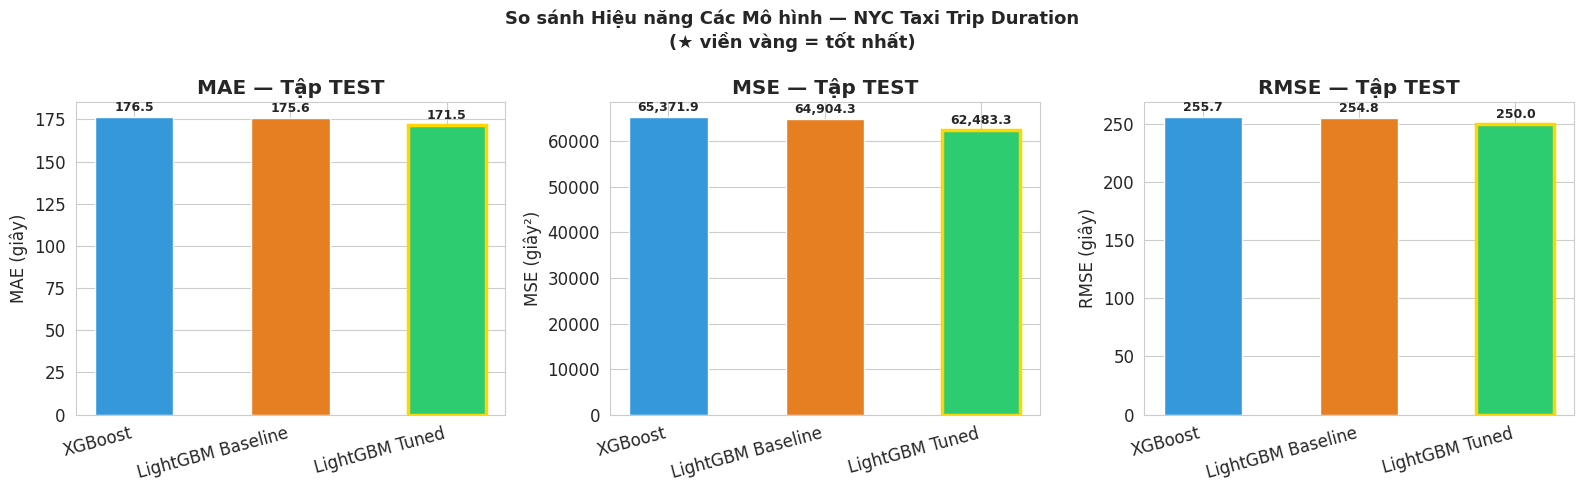

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models    = list(results_r2.keys())
colors    = ['#3498db', '#e67e22', '#2ecc71']

for ax, metric in zip(axes, ['MAE', 'MSE', 'RMSE']):
    vals = [results_r2[m][metric] for m in models]
    bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'{metric} — Tập TEST', fontweight='bold')
    ax.set_ylabel(f'{metric} (giây{"²" if metric=="MSE" else ""})')
    ax.set_xticklabels(models, rotation=15, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:,.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    # Đánh dấu best
    best_idx = vals.index(min(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('So sánh Hiệu năng Các Mô hình — NYC Taxi Trip Duration\n(★ viền vàng = tốt nhất)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Biểu đồ Predicted vs Actual — LightGBM Tuned

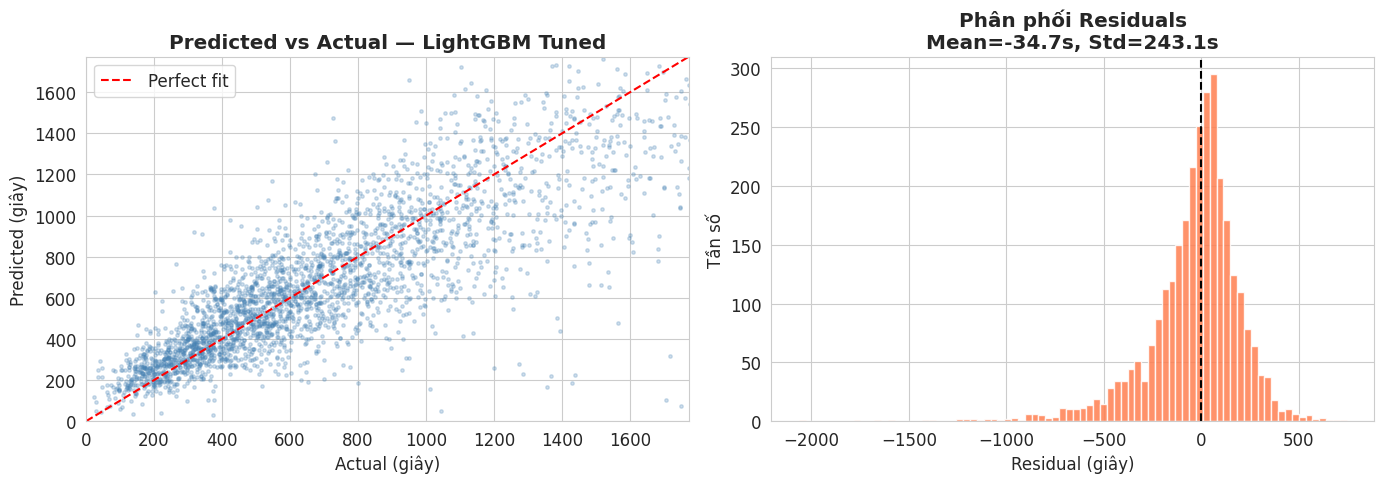

In [ ]:
sample_n = min(3000, len(y_true))
rng      = np.random.default_rng(42)
idx      = rng.choice(len(y_true), sample_n, replace=False)

y_true_s = y_true[idx]
y_pred_s = y_pred_lgb_tuned[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
lim_max = np.percentile(np.concatenate([y_true_s, y_pred_s]), 98)
axes[0].scatter(y_true_s, y_pred_s, alpha=0.25, s=6, color='steelblue')
axes[0].plot([0, lim_max], [0, lim_max], 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlim(0, lim_max); axes[0].set_ylim(0, lim_max)
axes[0].set_xlabel('Actual (giây)'); axes[0].set_ylabel('Predicted (giây)')
axes[0].set_title('Predicted vs Actual — LightGBM Tuned', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_pred_s - y_true_s
axes[1].hist(residuals, bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Residual (giây)'); axes[1].set_ylabel('Tần số')
axes[1].set_title(f'Phân phối Residuals\nMean={residuals.mean():.1f}s, Std={residuals.std():.1f}s',
                   fontweight='bold')

plt.tight_layout()
plt.show()


### 5.3 Optuna — Lịch sử tối ưu hóa

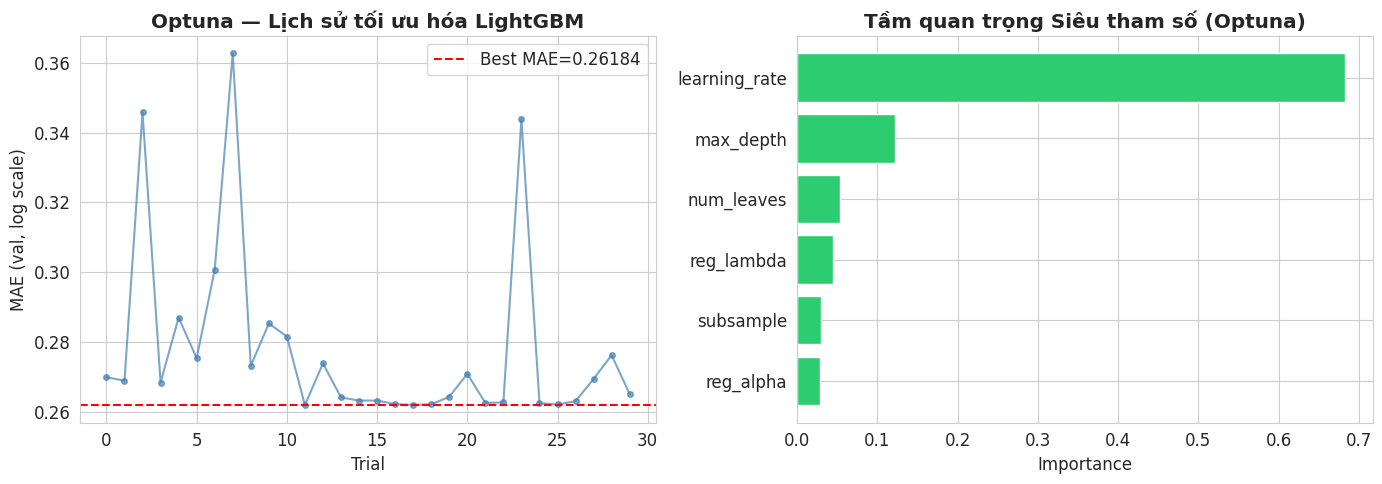

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trial_values = [t.value for t in study.trials]
axes[0].plot(trial_values, 'o-', color='steelblue', ms=4, alpha=0.7)
axes[0].axhline(study.best_value, color='red', ls='--', lw=1.5, label=f'Best MAE={study.best_value:.5f}')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('MAE (val, log scale)')
axes[0].set_title('Optuna — Lịch sử tối ưu hóa LightGBM', fontweight='bold')
axes[0].legend()

# Param importance (top 6)
try:
    param_imp = optuna.importance.get_param_importances(study)
    items = list(param_imp.items())[:6]
    names, imps = zip(*items)
    axes[1].barh(names, imps, color='#2ecc71', edgecolor='white')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Tầm quan trọng Siêu tham số (Optuna)', fontweight='bold')
    axes[1].invert_yaxis()
except Exception:
    axes[1].text(0.5, 0.5, 'Không tính được\nparam importance', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.show()


### 5.4 Tổng kết & Nhận xét
####Kết luận:
LightGBM  là mô hình tốt nhờ tối ưu hóa siêu tham số bằng Optuna.
- Khoảng cách (`haversine_dist`, `manhattan_dist`) và giờ đón (`pickup_hour`) là các features quan trọng nhất.
- với cơ chế Leaf-wise chỉ chọn duy nhất một nút lá có độ giảm sai số lớn nhất để tiếp tục chia nhánh, bất chấp cây có bị lệch hay không.
-  LightGBM dùng cấu trúc dữ liệu dự trên thùng chuyển đổi các giá trị liên tục thành các thùng cố định.
- LightGBM dùng thuật toán GOSS và EFB.
_______
#### so sánh với XGBoost:
- Thay vì mở rộng cây theo tầng như XGboost, LightGBM sẽ tập trung vào các nốt hay lá nào tiền năng để nhắm tới, mở rộng theo chiều sâu của dữ liệu giúp mô hình đi nhanh hơn.
- LIghtGBM có thể dùng được ngay kiểu dữ liệu chuỗi mà không cần phải chuyển đổi.
- LIghtGBM dùng ít tài nguyên hơi xo với XGboost

In [1]:
import json

def remove_widgets_metadata(notebook_path):
    try:
        with open(notebook_path, 'r', encoding='utf-8') as f:
            notebook_content = json.load(f)

        if 'metadata' in notebook_content and 'widgets' in notebook_content['metadata']:
            del notebook_content['metadata']['widgets']
            print(f"Đã xóa 'widgets' metadata từ {notebook_path}")

            with open(notebook_path, 'w', encoding='utf-8') as f:
                json.dump(notebook_content, f, indent=1)
            print(f"File {notebook_path} đã được lưu thành công.")
        else:
            print(f"Không tìm thấy 'widgets' metadata trong {notebook_path}. Không có gì để xóa.")

    except FileNotFoundError:
        print(f"Lỗi: File '{notebook_path}' không tồn tại.")
    except Exception as e:
        print(f"Đã xảy ra lỗi: {e}")

# Thay thế 'your_notebook_name.ipynb' bằng đường dẫn đến file notebook của bạn
# Ví dụ: 'my_project/my_notebook.ipynb'
notebook_file = '/content/your_notebook_name.ipynb' # <---- THAY THẾ ĐƯỜNG DẪN Ở ĐÂY

remove_widgets_metadata(notebook_file)


Lỗi: File '/content/your_notebook_name.ipynb' không tồn tại.
